In [1]:
COMB = "prod"
DATASET = "amusic"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{DATASET}/{STRATEGY}_{COMB}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\RESEARCH\2025-2 MDPI\BACF


In [4]:
import sys
sys.path.append("src")

# Config

In [5]:
import pandas as pd
import yaml
from recsys import config, experiment, bacf

In [6]:
kwargs = dict(
    file=PATH_CONFIG_FILE,
    mode="r",
    encoding="utf-8",
)
with open(**kwargs) as f:
    cfg = yaml.safe_load(f)

In [7]:
experiment_cfg = config.parser.experiment.experiment(cfg)
schema_cfg = config.parser.experiment.schema(cfg)
pipeline_cfg = config.parser.experiment.pipeline(cfg)
trainer_cfg = config.parser.experiment.trainer(cfg)
evaluator_cfg = config.parser.experiment.evaluator(cfg)
model_cfg = config.parser.model.auto(cfg)

In [8]:
experiment.utils.seed.reset(experiment_cfg)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{experiment_cfg.data}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    cfg=schema_cfg,
    percentaile=0.9,
)

experiment.utils.data_handler.description(**kwargs)

number of user: 5541
number of item: 3568
total interaction: 64706
interaction density: 0.3273 %
max interaction of user: 578
max interaction of item: 272
top 10.0 % interaction of user: 20.0
top 10.0 % interaction of item: 40.0
mean interaction of user: 11
mean interaction of item: 18


In [11]:
kwargs = dict(
    df=df,
    cfg=pipeline_cfg,
)

dataloaders, interactions, histories = experiment.pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [12]:
kwargs = dict(
    histories=histories["user"],
    cfg=model_cfg,
)

model = bacf.model.Module(**kwargs)

# Train

In [13]:
kwargs = dict(
    model=model,
    cfg=trainer_cfg,
)

trainer = experiment.trainer.builder.trainer_builder(**kwargs)

In [14]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
    dev_loader=dataloaders["dev"],
)

record = trainer.fit(**kwargs)

DEVELOPMENT
	BEST SCORE: 0.4484
	BEST EPOCH: 13


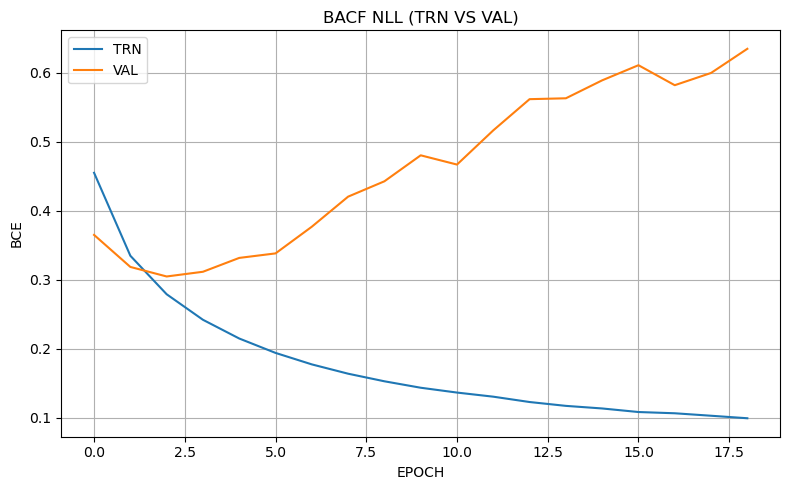

In [15]:
kwargs = dict(
    records=[record["trn"]["nll"], record["val"]["nll"]],
    labels=["TRN", "VAL"],
    criterion="BCE",
    title="BACF NLL (TRN VS VAL)"
)

experiment.utils.visualizer.compare_curve(**kwargs)

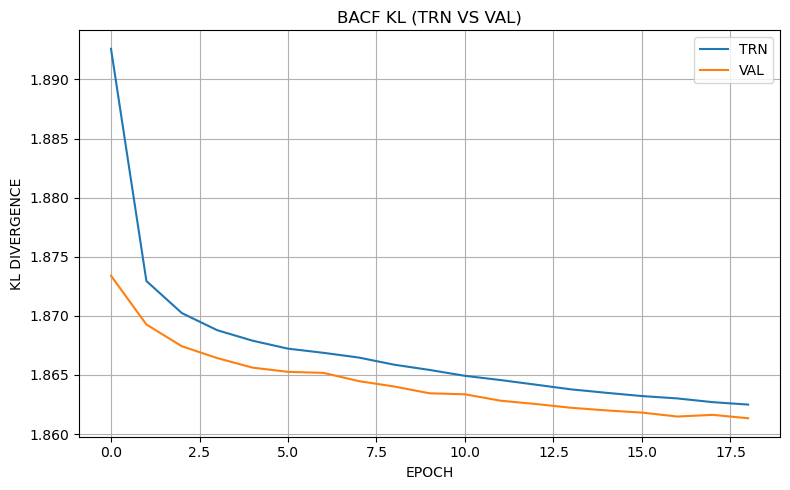

In [16]:
kwargs = dict(
    records=[record["trn"]["kl"], record["val"]["kl"]],
    labels=["TRN", "VAL"],
    criterion="KL DIVERGENCE",
    title="BACF KL (TRN VS VAL)"
)

experiment.utils.visualizer.compare_curve(**kwargs)

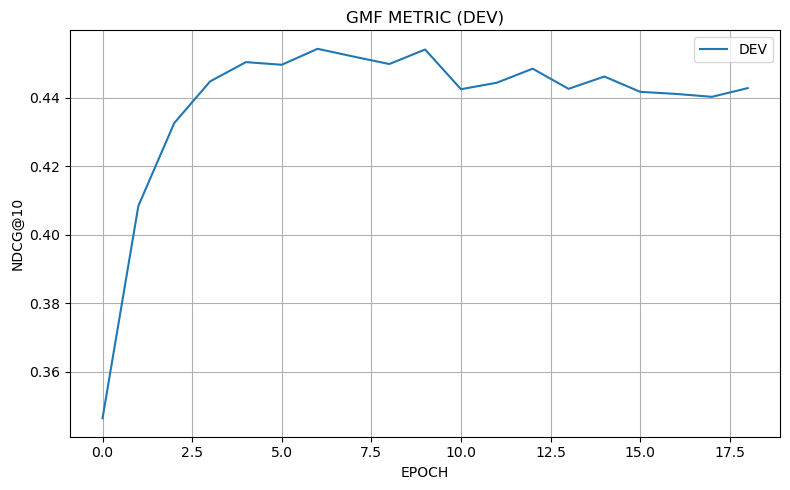

In [17]:
kwargs = dict(
    record=record["dev"],
    label="DEV",
    criterion="NDCG@10",
    title="GMF METRIC (DEV)",
)

experiment.utils.visualizer.criterion_curve(**kwargs)

# Test

In [18]:
kwargs = dict(
    model=model,
    cfg=evaluator_cfg,
)

evaluator = experiment.evaluator.builder.evaluator_builder(**kwargs)

In [19]:
result, metrics_sheet = evaluator(dataloaders["tst"])

TST: 100%|██████████| 2390/2390 [00:13<00:00, 177.56it/s]


In [20]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.587270,0.129935,0.524616,0.343123,0.400576
1,10,0.721034,0.084635,0.660394,0.364347,0.446663
2,15,0.790651,0.063882,0.733394,0.371452,0.467477
3,20,0.838140,0.051703,0.784574,0.374984,0.480466
4,25,0.866982,0.043560,0.818400,0.377015,0.488642
5,50,0.949279,0.024918,0.913150,0.380660,0.508800


# Save

In [21]:
PATH = f'./checkpoints/{experiment_cfg.data}/{experiment_cfg.strategy}_{experiment_cfg.comb}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

experiment.utils.checkpointer.save(**kwargs)